<a href="https://colab.research.google.com/github/s-grzhang/necrophobia-filter/blob/master/Necrophobia_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Objectives

##Images to CSV File

##Stabilize training
###K-Fold Cross-Validation

##Fix test output so it doesn't output index 0 of class array every time.

##Tune hyperparameters

In [2]:
#image size optimization tips: https://medium.com/analytics-vidhya/how-to-pick-the-optimal-image-size-for-training-convolution-neural-network-65702b880f05
# retrieves average image dimensions of a folder in order to optimize dimensions
'''import os
import PIL
from PIL import Image

widths = []
heights = []

#dir_path = r"/home/grace/necrophobia-filter/Dataset/train/Disturbing" # Adding 'r' to make the string a raw string

for img_name in os.listdir(dir_path):
    if img_name.endswith(".jpg") or img_name.endswith(".png") or img_name.endswith(".jpeg") or img_name.endswith(".bmp"):
        img_path = os.path.join(dir_path, img_name) # Adding img_name to the path
        im = Image.open(img_path)
        widths.append(im.size[0])
        heights.append(im.size[1])

AVG_HEIGHT = round(sum(heights)/len(heights))
AVG_WIDTH = round(sum(widths)/len(widths))

print(f"Average Disturbing Height: {AVG_HEIGHT}")
print(f"Average Disturbing Width: {AVG_WIDTH}")

widths = []
heights = []

#dir_path = r"/home/grace/necrophobia-filter/Dataset/train/Not Disturbing" # Adding 'r' to make the string a raw string

for img_name in os.listdir(dir_path):
    if img_name.endswith(".jpg") or img_name.endswith(".png") or img_name.endswith(".jpeg") or img_name.endswith(".bmp"):
        img_path = os.path.join(dir_path, img_name) # Adding img_name to the path
        im = Image.open(img_path)
        widths.append(im.size[0])
        heights.append(im.size[1])

AVG_HEIGHT = round(sum(heights)/len(heights))
AVG_WIDTH = round(sum(widths)/len(widths))

print(f"Average Not Disturbing Height: {AVG_HEIGHT}")
print(f"Average Not Disturbing Width: {AVG_WIDTH}")'''

'import os\nimport PIL\nfrom PIL import Image\n\nwidths = []\nheights = []\n\n#dir_path = r"/home/grace/necrophobia-filter/Dataset/train/Disturbing" # Adding \'r\' to make the string a raw string\n\nfor img_name in os.listdir(dir_path):\n    if img_name.endswith(".jpg") or img_name.endswith(".png") or img_name.endswith(".jpeg") or img_name.endswith(".bmp"):\n        img_path = os.path.join(dir_path, img_name) # Adding img_name to the path\n        im = Image.open(img_path)\n        widths.append(im.size[0])\n        heights.append(im.size[1])\n\nAVG_HEIGHT = round(sum(heights)/len(heights))\nAVG_WIDTH = round(sum(widths)/len(widths))\n\nprint(f"Average Disturbing Height: {AVG_HEIGHT}")\nprint(f"Average Disturbing Width: {AVG_WIDTH}")\n\nwidths = []\nheights = []\n\n#dir_path = r"/home/grace/necrophobia-filter/Dataset/train/Not Disturbing" # Adding \'r\' to make the string a raw string\n\nfor img_name in os.listdir(dir_path):\n    if img_name.endswith(".jpg") or img_name.endswith(".png"

In [3]:
#Image Preprocessing
import tensorflow as tf
import tensorflow

from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential

import os
import cv2
import numpy as np

#CNN Model
from tensorflow import keras
from tensorflow.keras import callbacks, layers
from tensorflow.keras import initializers

In [4]:
train_path='/content/drive/MyDrive/Dataset/train'
test_path='/content/drive/MyDrive/Dataset/test'
val_path='/content/drive/MyDrive/Dataset/validation'
x_train=[]

for folder in os.listdir(train_path):

    sub_path=train_path+"/"+folder

    for img in os.listdir(sub_path):

        image_path=sub_path+"/"+img

        img_arr=cv2.imread(image_path)

        img_arr=cv2.resize(img_arr,(300, 300))

        x_train.append(img_arr)

x_test=[]

for folder in os.listdir(test_path):

    sub_path=test_path+"/"+folder

    for img in os.listdir(sub_path):

        image_path=sub_path+"/"+img

        img_arr=cv2.imread(image_path)

        img_arr=cv2.resize(img_arr,(300, 300))

        x_test.append(img_arr)

x_val=[]

for folder in os.listdir(val_path):

    sub_path=val_path+"/"+folder

    for img in os.listdir(sub_path):

        image_path=sub_path+"/"+img

        img_arr=cv2.imread(image_path)

        img_arr=cv2.resize(img_arr,(300, 300))

        x_val.append(img_arr)
train_x=np.array(x_train)
test_x=np.array(x_test)
val_x=np.array(x_val)
'''train_x=train_x/255.0
test_x=test_x/255.0
val_x=val_x/255.0'''

'train_x=train_x/255.0\ntest_x=test_x/255.0\nval_x=val_x/255.0'

In [5]:
#Image Preprocessing

#Borrowed from https://www.analyticsvidhya.com/blog/2021/07/step-by-step-guide-for-image-classification-on-custom-datasets/

#Code and explanation found here: https://www.geeksforgeeks.org/cnn-image-data-pre-processing-with-generators/
#Another good explanation: https://machinelearningmastery.com/how-to-load-large-datasets-from-directories-for-deep-learning-with-keras/
train_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)
validation_datagen = ImageDataGenerator(rescale = 1./225)

train_generator = train_datagen.flow_from_directory(
                  train_path, #Data augmentation?
                  target_size =(300, 300),
                  color_mode = 'grayscale',
                  batch_size = 29,
                  shuffle=True,
                  class_mode ='binary')


test_generator = test_datagen.flow_from_directory(
                    test_path,
                    target_size =(300, 300),
                    color_mode = 'grayscale',
                    batch_size = 29,
                    shuffle=True,
                    class_mode ='binary')
validation_generator = validation_datagen.flow_from_directory(
                    val_path,
                    target_size =(300, 300),
                    color_mode = 'grayscale',
                    batch_size = 29,
                    shuffle=True,
                    class_mode ='binary')

#prints shape of data
batchX, batchy = train_generator.next()
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape, batchX.min(), batchX.max()))

train_y=train_generator.classes
test_y=test_generator.classes
val_y=validation_generator.classes
#Not one-hot encoded
train_generator.class_indices
train_y.shape,test_y.shape,val_y.shape

Found 370 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Batch shape=(29, 300, 300, 1), min=0.000, max=1.000


((370,), (30,), (50,))

In [6]:
#CNN Model

initializer = tf.keras.initializers.HeNormal(seed=42)
model = keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=3, activation='relu', kernel_initializer=initializer, input_shape=(300, 300, 1),padding = 'same'),# https://www.geeksforgeeks.org/weight-initialization-techniques-for-deep-neural-networks/
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=32, kernel_size=3, activation='relu', kernel_initializer=initializer, padding = 'same'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=3, activation='relu', kernel_initializer=initializer, padding = 'same'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=128, kernel_size=3, activation='relu', kernel_initializer=initializer,padding = 'same'),
    layers.Conv2D(filters=128, kernel_size=3, activation='relu', kernel_initializer=initializer,padding = 'same'),
    layers.Conv2D(filters=64, kernel_size=3, activation='relu', kernel_initializer=initializer,padding = 'same'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    layers.Dropout(rate=0.5),
    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(units=1, activation="sigmoid"),
])

# example of loading the vgg16 model
'''from tensorflow.keras.layers import Input, Lambda, Dense, Flatten,Dropout
from keras.applications.vgg16 import VGG16
IMAGE_SIZE=[224,224]
model = VGG16(input_shape=IMAGE_SIZE + [3],weights='imagenet', include_top=False)

for layer in model.layers:
    layer.trainable = False
x = Flatten()(model.output)
#adding output layer.Softmax classifier is used as it is multi-class classification
prediction = Dense(1, activation="sigmoid")(x)
model = Model(inputs=model.input, outputs=prediction)'''
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 300, 300, 16)      160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 150, 150, 16)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 75, 75, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 37, 37, 64)        0

In [7]:
model.compile(
    optimizer='adam', #smaller learning rate to stabilize training?
    loss='binary_crossentropy', #Does not need one-hot encoding
    metrics=['binary_accuracy']
)
early_stopping = callbacks.EarlyStopping(
    #min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
    monitor='val_loss',
    mode='min',
)

In [8]:
tf.config.run_functions_eagerly(True)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/tensorflow/python/data/ops/structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


13/13 [==============================] - 21s 884ms/step - loss: 0.5922 - binary_accuracy: 0.7486 - val_loss: 9.3794 - val_binary_accuracy: 0.4200
Epoch 2/20
13/13 [==============================] - 10s 747ms/step - loss: 0.4229 - binary_accuracy: 0.8243 - val_loss: 5.4038 - val_binary_accuracy: 0.4200
Epoch 3/20
13/13 [==============================] - 10s 742ms/step - loss: 0.3713 - binary_accuracy: 0.8514 - val_loss: 2.0996 - val_binary_accuracy: 0.4200
Epoch 4/20
13/13 [==============================] - 8s 607ms/step - loss: 0.3285 - binary_accuracy: 0.8703 - val_loss: 1.9721 - val_binary_accuracy: 0.4200
Epoch 5/20
13/13 [==============================] - 9s 726ms/step - loss: 0.2856 - binary_accuracy: 0.8892 - val_loss: 1.6291 - val_binary_accuracy: 0.4400
Epoch 6/20
13/13 [==============================] - 8s 664ms/step - loss: 0.2256 - binary_accuracy: 0.9324 - val_loss: 1.0106 - val_binary_accuracy: 0.5000
Epoch 7/20
13/13 [==============================] - 8s 649ms/step - loss

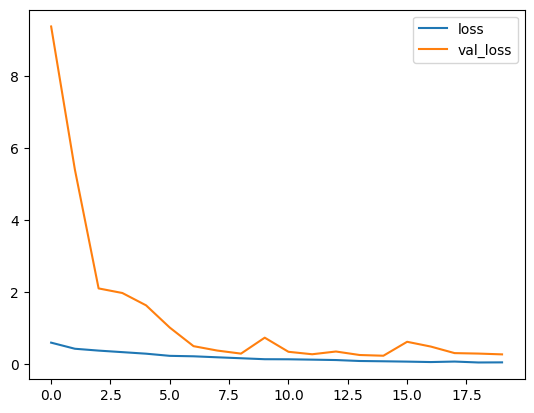

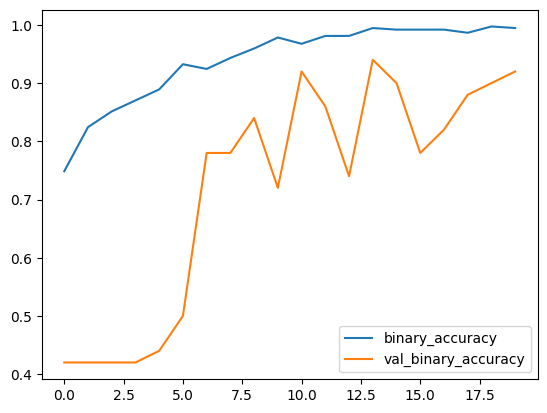

In [9]:
import pandas as pd

history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();